**Author: Rani Adhaduk
Email: rani.adhaduk@gmail.com
Created on: 2025-05-01
Last modified: 2025-05-01
Description: This script performs multiple linear regression on a dataset
             Economics Dataset.**

## About the Dataset
This dataset is a synthetic collection of economic indicators spanning a 100-year period, featuring monthly entries for key financial metrics such as interest rates, unemployment levels, and stock index values. With 1,200 data points

## Lesson Learned:

I gained experience working with multiple independent data operations, such as dropping unnecessary features, analyzing the correlation between features and the target variable, and applying cross-validation techniques during model training. I also learned how to calculate performance metrics and compared a linear regression model with an OLS (Ordinary Least Squares) model by examining their coefficients.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

c:\users\adhadra\miniconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df=pd.read_csv('C:\\Users\\ADHADRA\\OneDrive - CPGGPC\\Desktop\\archive\\modified_synthetic_economic_data.csv');

In [3]:
df.head()

,year,month,interest_rate,unemployment_rate,index_price
0,1924,1,3.50,5.19,534.714897
1,1925,1,2.86,4.36,424.911412
2,1926,1,3.65,5.18,582.253910
3,1927,1,4.52,5.81,784.797318
4,1928,1,2.77,5.07,321.169866


In [4]:
df.drop(columns=["year","month"],axis=1,inplace=True) #drop unneccssary columns as index_price doesnot depend on year and month

In [5]:
df.head()

,interest_rate,unemployment_rate,index_price
0,3.50,5.19,534.714897
1,2.86,4.36,424.911412
2,3.65,5.18,582.253910
3,4.52,5.81,784.797318
4,2.77,5.07,321.169866


In [6]:
##check null values 
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

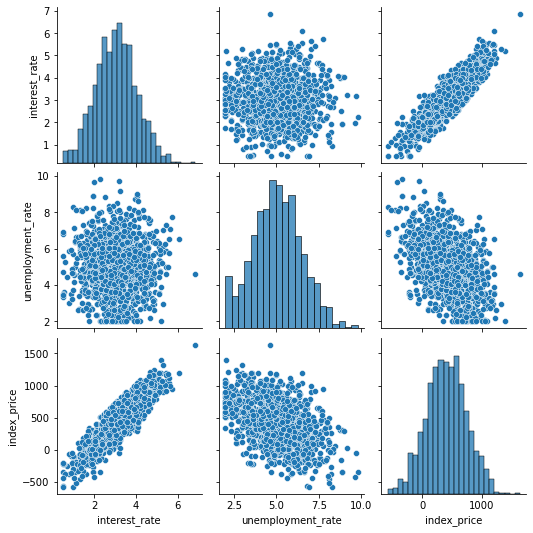

In [7]:
## Seaborn for visualization
import seaborn as sns
sns.pairplot(df)

In [8]:
df.corr() #index_price and interest_rate are positively correlated and index_price and unemployment rate are negatively correlated
#That means when interest_rate increases index_price also increase and vica versa
# there is no relation between interest rate and unemployment rate

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,0.014553,0.890899
unemployment_rate,0.014553,1.000000,-0.441184
index_price,0.890899,-0.441184,1.000000


In [9]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [10]:
## Train and Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

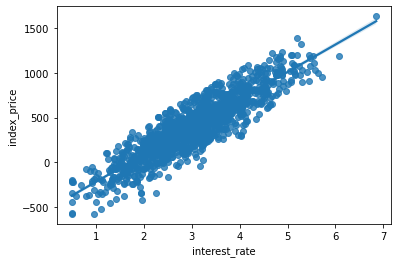

In [11]:
import seaborn as sns
#sns.regplot(df['interest_rate'],df['index_price'])
sns.regplot(x='interest_rate', y='index_price', data=df)
plt.show()

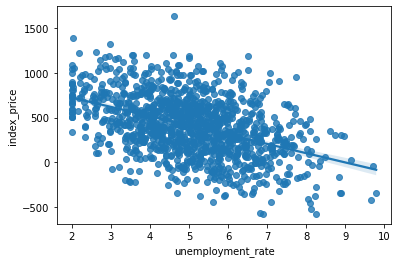

In [12]:
sns.regplot(x='unemployment_rate', y='index_price', data=df)
plt.show()

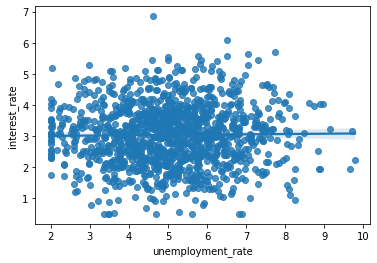

In [13]:
sns.regplot(x='unemployment_rate', y='interest_rate', data=df)
plt.show()

In [14]:
## Standardization is required on independent variable as to help converge faster to find global minima and mean=0 and std deviation=1 for that specific feature
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train) 
X_test=scaler.transform(X_test)

In [15]:
X_train

array([[ 0.48555446,  1.1362148 ],
       [ 1.53650812, -1.50284267],
       [-1.14810617, -1.16432483],
       ...,
       [ 0.30866127, -0.32839301],
       [ 0.18379549,  0.8598737 ],
       [ 0.28785031, -1.1574163 ]])

In [16]:
from sklearn.linear_model import LinearRegression

regression = LinearRegression(n_jobs=-1)
regression.fit(X_train,y_train)

LinearRegression(n_jobs=-1)

In [17]:
# Cross validation
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',cv=10)
np.mean(validation_score)

-0.682157486276244

In [18]:
##Prediction for test data
y_pred = regression.predict(X_test)

In [19]:
## Performance Matrix
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

0.28432556206465903
0.2160572533079026
0.5332218694546005


In [20]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)

In [21]:
print(score)

0.9999975863799279


In [22]:
AdjR2 = 1- (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

In [23]:
AdjR2

0.9999975701265941

## Assumptions

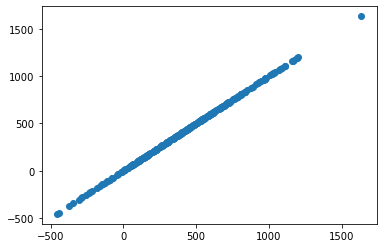

In [24]:
plt.scatter(y_test,y_pred)

In [25]:
residuals=y_test-y_pred
type(residuals)

pandas.core.series.Series

In [26]:
residuals.shape

(300,)

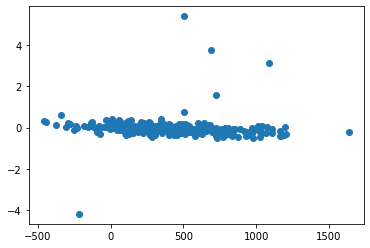

In [30]:
## scatter plot with respect to residuals and prediction
plt.scatter(y_pred,residuals)

In [31]:
## OLS linear Regression
import statsmodels.api as sm
model=sm.OLS(y_train,X_train).fit()

In [32]:
prediction= model.predict(X_test)
print(prediction)

[-2.44180855e+02 -3.14644829e+01 -2.92812597e+02  1.48808344e+02
  2.12047197e+02  2.70173094e+02  7.98279328e+02 -9.48224163e+00
 -1.00788935e+02 -4.88215251e+01 -1.74295758e+02 -3.58714392e+02
 -3.00274476e+02 -1.92347991e+02 -3.54122890e+02 -2.51626006e+02
  7.49903698e+01 -2.34372681e+02  3.04629321e+02  4.04056759e+02
 -2.95932467e+02  3.18459989e+02 -2.57888211e+02 -5.30626849e+01
 -1.00999237e+02 -2.56769789e+02  5.72186347e+02 -4.74496189e+00
 -1.43492087e+02 -3.11829109e+02 -1.10546685e+02  5.41890028e+02
 -2.68879331e+02  1.50963934e+02  2.82826553e+02 -3.59130764e+01
  5.39395929e+00 -6.70111707e+01  8.96311772e+01  1.03994531e+02
 -5.41871696e+02  5.03031259e+01 -2.81126287e+02 -3.72236778e+02
 -5.01081881e+01 -1.94994205e+02  2.66418186e+01 -5.09924270e+02
  6.58577892e+01  4.74513732e+02  2.25597543e+02  2.02309043e+02
 -8.26050260e+01 -1.01764447e+02  4.08565263e+01 -2.99311941e+01
 -3.32375382e+00  1.90128209e+00  3.12727601e+02 -1.34564072e+02
 -3.02570347e+02  9.68101

In [33]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.413
Model:                            OLS   Adj. R-squared (uncentered):              0.412
Method:                 Least Squares   F-statistic:                              315.8
Date:                Thu, 01 May 2025   Prob (F-statistic):                   1.43e-104
Time:                        12:06:39   Log-Likelihood:                         -6677.3
No. Observations:                 900   AIC:                                  1.336e+04
Df Residuals:                     898   BIC:                                  1.337e+04
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [34]:
print(regression.coef_)

[ 297.94623606 -154.59112154]


In [ ]:
#Hence the coefficients matches